<a href="https://colab.research.google.com/github/usman-infinity/Final_For_The_Research_Paper-/blob/main/MODEL%3ECNN_BiGRU_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pakistan_air_quality_final_clean.csv to pakistan_air_quality_final_clean.csv
Dataset Columns: Index(['timestamp', 'city', 'latitude', 'longitude', 'pm10', 'pm2_5',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed',
       'wind_direction', 'pressure', 'date', 'hour', 'day_of_week', 'month',
       'month_name', 'year', 'is_weekend', 'season', 'aqi_category'],
      dtype='object')
Dataset shape after cleaning: (21840, 2)
X shape: (21815, 24, 2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 12, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,066 (406.51 KB)

 Trainable params: 104,066 (406.51 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 293s 16ms/step - loss: 0.0024 - mae: 0.0305 - val_loss: 9.4334e-04 - val_mae: 0.0207
Epoch 2/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 277s 16ms/step - loss: 0.0011 - mae: 0.0226 - val_loss: 3.9870e-04 - val_mae: 0.0145
Epoch 3/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 275s 16ms/step - loss: 9.1958e-04 - mae: 0.0204 - val_loss: 3.1114e-04 - val_mae: 0.0109
Epoch 4/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 278s 16ms/step - loss: 8.3371e-04 - mae: 0.0195 - val_loss: 4.9032e-04 - val_mae: 0.0142
Epoch 5/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 286s 16ms/step - loss: 7.8001e-04 - mae: 0.0189 - val_loss: 3.3783e-04 - val_mae: 0.0120
Epoch 6/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 283s 16ms/step - loss: 7.5855e-04 - mae: 0.0185 - val_loss: 4.1448e-04 - val_mae: 0.0125
Epoch 7/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 280s 16ms/step - loss: 7.3039e-04 - mae: 0.0181 - val_loss: 4.0185e-04 - val_mae: 0.0137
Epoch 8/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 286s 16ms/s

,Pollutant,MAE,RMSE,R2
0,PM10,9.4299,11.6452,0.9558
1,PM25,8.5117,10.8773,0.9609


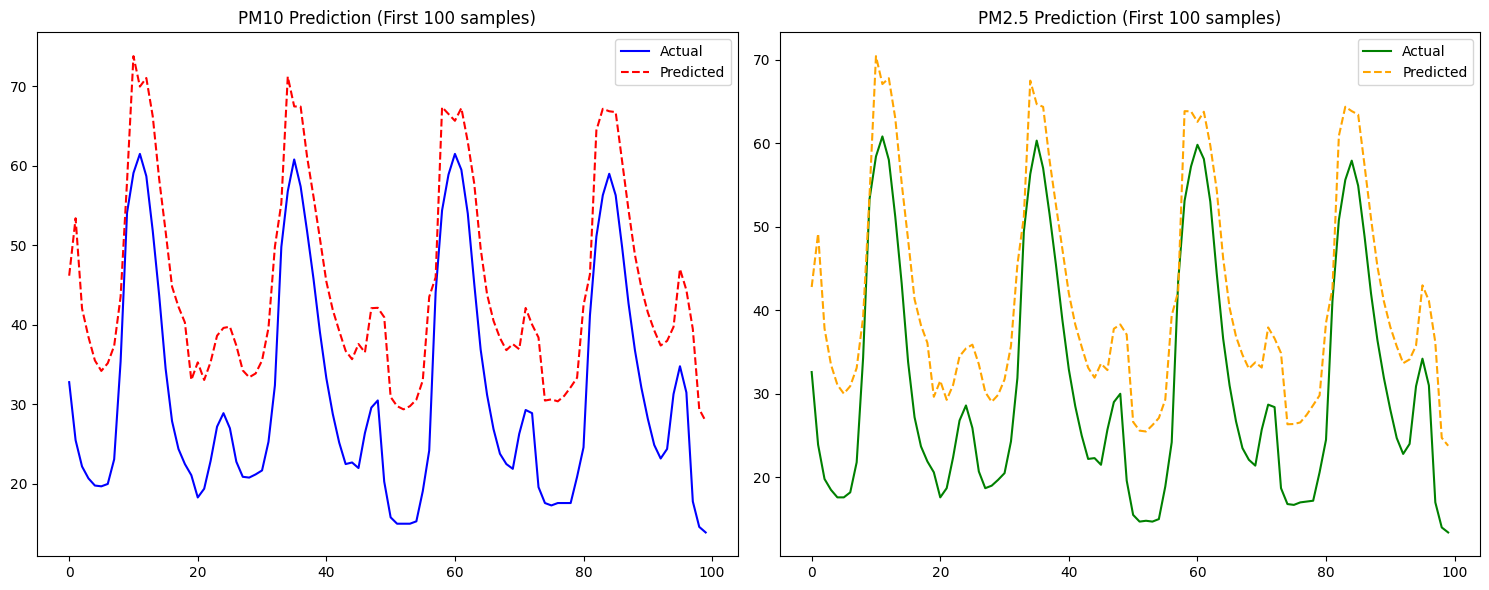

Model saved as 'cnn_bigru_lstm_model.h5'


In [6]:
# =========================================================
# 🚀 GOOGLE COLAB FULL CODE: CNN + BiGRU + LSTM
# =========================================================

# ----------------------------
# 0️⃣ Install & Setup
# ----------------------------
!pip install -q tensorflow scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------
# 1️⃣ Upload Dataset
# ----------------------------
from google.colab import files
uploaded = files.upload()

# Load dataset
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Dataset Columns:", df.columns)

# ----------------------------
# 2️⃣ Data Preprocessing
# ----------------------------
# Normalize column names
df.rename(columns={'pm2_5':'pm25', 'PM2.5':'pm25', 'PM10':'pm10'}, inplace=True)
df = df[['timestamp','pm10','pm25']]

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Handle missing values
df = df.dropna()
print("Dataset shape after cleaning:", df.shape)

# ----------------------------
# 3️⃣ Normalize Data
# ----------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# ----------------------------
# 4️⃣ Create Time-Series Dataset
# ----------------------------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), :])
        y.append(data[i+time_step, :])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)
print("X shape:", X.shape) # Expected: (samples, 24, 2)

# ----------------------------
# 5️⃣ Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ----------------------------
# 6️⃣ Positional Encoding (Optional but kept for Hybrid Structure)
# ----------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(seq_len, d_model)

    def get_angles(self, pos, i, d_model):
        angles = 1 / np.power(10000, (2*(i//2))/np.float32(d_model))
        return pos * angles

    def positional_encoding(self, seq_len, d_model):
        angle_rads = self.get_angles(
            np.arange(seq_len)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model
        )
        angle_rads[:,0::2] = np.sin(angle_rads[:,0::2])
        angle_rads[:,1::2] = np.cos(angle_rads[:,1::2])
        return tf.cast(angle_rads[np.newaxis,...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

# ----------------------------
# 7️⃣ Build Model (CNN + BiGRU + LSTM)
# ----------------------------
d_model = 64

inputs = layers.Input(shape=(time_step, 2))

# A. CNN for Spatial/Local Feature Extraction
x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

# B. Match Dimensions for Recurrent Layers
x = layers.Dense(d_model)(x)
x = PositionalEncoding(time_step // 2, d_model)(x)

# C. BiGRU for Bidirectional Temporal Context
x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)

# D. LSTM for Long-term Dependency Capture
x = layers.LSTM(64, return_sequences=False)(x)

# E. Output Head
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(2)(x) # Predicting both PM10 and PM25

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ----------------------------
# 8️⃣ Train Model
# ----------------------------
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# 9️⃣ Prediction & Evaluation
# ----------------------------
predictions = model.predict(X_test)

# Inverse scaling
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

# Calculate Metrics for PM10
mae_pm10 = mean_absolute_error(y_test_inv[:, 0], predictions_inv[:, 0])
rmse_pm10 = np.sqrt(mean_squared_error(y_test_inv[:, 0], predictions_inv[:, 0]))
r2_pm10 = r2_score(y_test_inv[:, 0], predictions_inv[:, 0])

# Calculate Metrics for PM2.5
mae_pm25 = mean_absolute_error(y_test_inv[:, 1], predictions_inv[:, 1])
rmse_pm25 = np.sqrt(mean_squared_error(y_test_inv[:, 1], predictions_inv[:, 1]))
r2_pm25 = r2_score(y_test_inv[:, 1], predictions_inv[:, 1])

# Create a DataFrame for structured output
metrics_data = {
    'Pollutant': ['PM10', 'PM25'],
    'MAE': [mae_pm10, mae_pm25],
    'RMSE': [rmse_pm10, rmse_pm25],
    'R2': [r2_pm10, r2_pm25]
}
metrics_df = pd.DataFrame(metrics_data)

print("\nModel Evaluation Metrics:")
display(metrics_df.round(4))

# ----------------------------
# 🔟 Visualization
# ----------------------------
plt.figure(figsize=(15, 6))

# PM10 Plot
plt.subplot(1, 2, 1)
plt.plot(y_test_inv[:100, 0], label='Actual', color='blue')
plt.plot(predictions_inv[:100, 0], label='Predicted', color='red', linestyle='--')
plt.title("PM10 Prediction (First 100 samples)")
plt.legend()

# PM2.5 Plot
plt.subplot(1, 2, 2)
plt.plot(y_test_inv[:100, 1], label='Actual', color='green')
plt.plot(predictions_inv[:100, 1], label='Predicted', color='orange', linestyle='--')
plt.title("PM2.5 Prediction (First 100 samples)")
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# 1️⃣1️⃣ Save Model
# ----------------------------
model.save('cnn_bigru_lstm_model.h5')
print("Model saved as 'cnn_bigru_lstm_model.h5'")